<a href="https://colab.research.google.com/github/Marcomaltoni/Advanced_deep_learning/blob/main/Diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import seaborn as sns  # a useful plotting library on top of matplotlib
from tqdm.auto import tqdm # a nice progress bar

In [ ]:
sns.set_context("talk")

In [ ]:
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"I'm using: {device}")

I'm using: cuda


# Data generation and loading #

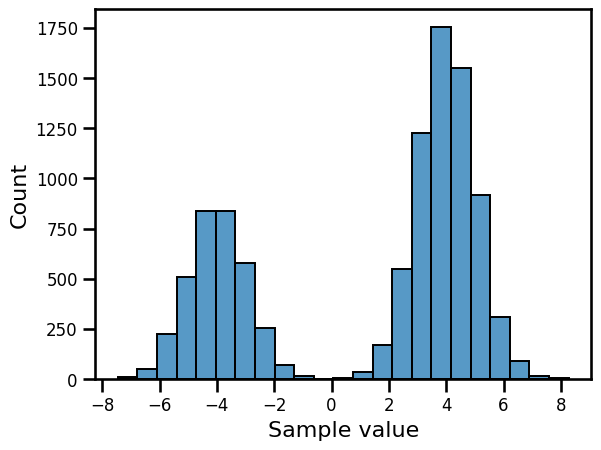

In [ ]:
# generate a dataset of 1D data from a mixture of two Gaussians
# this is a simple example, but you can use any distribution
data_distribution = torch.distributions.mixture_same_family.MixtureSameFamily(
    torch.distributions.Categorical(torch.tensor([1, 2])),
    torch.distributions.Normal(torch.tensor([-4., 4.]), torch.tensor([1., 1.]))
)

dataset = data_distribution.sample(torch.Size([10000]))  # create training data set
dataset_validation = data_distribution.sample(torch.Size([1000])) # create validation data set

fig, ax = plt.subplots(1, 1)
sns.histplot(dataset)
ax.set(xlabel='Sample value')
plt.show()

In [ ]:
time_steps = 250
beta = torch.tensor(0.02).to(device)
n_epochs = 1000
batch_size = 64
learning_rate = 0.8e-4

# Model implementation #

The model must predict the noise added at each step of the noising process by taking as an input the noisy image and the time step.

In [ ]:
class Diffusion(nn.Module):
  def __init__(self):
    super(Diffusion, self).__init__()
    self.noising = nn.Sequential(
        nn.Linear(2, 32),
        nn.ReLU(),
        nn.LayerNorm(32), # Better than batchnorm, it normalizes the layer output not considering all the others elements in the batch

        nn.Linear(32, 64),
        nn.ReLU(),
        nn.LayerNorm(64),

        nn.Linear(64, 32),
        nn.ReLU(),
        nn.LayerNorm(32),

        nn.Linear(32, 1)
    )

  def forward(self, current_sample, t):
    x = torch.cat((current_sample, t), 1)
    return self.noising(x)

model = Diffusion()
model.to(device)

print(model)

Diffusion(
  (noising): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (3): Linear(in_features=32, out_features=64, bias=True)
    (4): ReLU()
    (5): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)


# Training #

For each epoch, a sample and a timestep are chosen, and the noisy image is computed as $$ x_t = \sqrt{\prod_{i=0}^{t} (1 - \beta)} \cdot x_0+\sqrt{1-\prod_{i=0}^{t} (1-\beta)} \cdot \epsilon_t$$ with $\epsilon_t$ a random noise sampled from a gaussian with mean zero and standard deviation 1. By taking into account the noisy image and the timestep, the model has to estimate the added noise.

In [ ]:
loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
epochs = tqdm(range(n_epochs))  # this makes a nice progress bar
loss_train = []
loss_val = []
val_t = torch.randint(low=1, high=time_steps + 1, size=(dataset_validation.shape[0],), device = device).unsqueeze(1) #for the validation a fixed vector of losses and
#timesteps is consider in order to track if the model is really improving. Unsqueeze makes all the tensors of dimension [batch_size, 1]
val_noise = torch.randn(size=dataset_validation.shape).to(device).unsqueeze(1)
for e in epochs:
  model.train()
  # loop through batches of the dataset, reshuffling it each epoch
  indices = torch.randperm(dataset.shape[0]) #generate random permutation of all the indices
  shuffled_dataset = dataset[indices] #reorders the dataset elements using the new index permutation: at each epoch the data order changes to not create a bias
  loss_train_val = []
  for i in range(0, shuffled_dataset.shape[0] - batch_size, batch_size): #i takes the value of all the elements of the dataset associated to the end of a batch
    # sample a batch of data
    x0 = shuffled_dataset[i:i + batch_size].unsqueeze(1).to(device) #takes all the elements in each batch
    timestep = torch.randint(low=1, high=time_steps + 1, size=(x0.shape[0],), device=device).unsqueeze(1) #sample timesteps with same dimension as batch size from a
    #uniform distribution between 0 and 250
    noise = torch.randn_like(x0)# sample noise values with same dimension as batch size from a standard gaussian. Already x0 dimension, no need for unsqueeze
    noisy_image = torch.sqrt(torch.pow((1-beta), timestep))*x0 + torch.sqrt(1-torch.pow((1-beta),timestep))*noise #compute the noisy image
    pred_noise = model(noisy_image,timestep.float()) #concatenation of float 64 and integer, better to convert the integer timesteps into floats
    l = loss(pred_noise, noise)
    loss_train_val.append(l.item())
    optimizer.zero_grad()
    l.backward()
    optimizer.step()

  loss_train.append(np.mean(loss_train_val))

  # compute the loss on the validation set
  model.eval()
  with torch.no_grad():
    x0 = dataset_validation.unsqueeze(1).to(device)
    noisy_image = torch.sqrt(torch.pow((1-beta),val_t))*x0 + torch.sqrt(1-torch.pow((1-beta),val_t))*val_noise
    pred_noise = model(noisy_image,val_t.float())
    l = loss(pred_noise, val_noise)
    loss_val.append(l.item())

  epochs.set_description(f"Loss train: {loss_train[-1]:.4f}; Loss validation: {loss_val[-1]:.4f}")



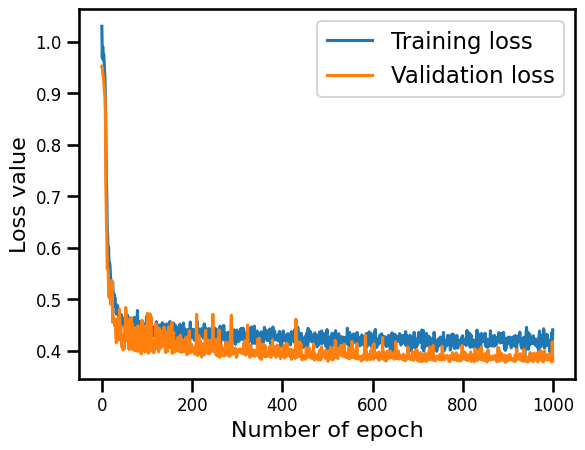

In [ ]:
plt.figure()
plt.xlabel('Number of epoch')
plt.ylabel('Loss value')
plt.plot(range(n_epochs), loss_train, label='Training loss')
plt.plot(range(n_epochs), loss_val, label='Validation loss')
plt.legend()
plt.show()

# Sample generation #

By starting from a noisy random gaussian sample the model is now capable of predicting the noise at each timestep to subtract in order to get to a sample of the dataset. In particular, all the 250 timesteps are considered, and at each step the noisy sample and the timestep are input of the model that predicts the noise to substract to get closer to the dataset sample. The denoised image at the timestep t is: $$ x_{t-1}=\frac{1}{\sqrt{(1-\beta)}}\left(x_t - \frac{\beta}{\sqrt{1-\prod_{i=0}^{t} (1-\beta)}} \epsilon_{\theta}(x_t,t)\right) + \sigma_t \cdot z$$
with z a random noise sampled from a standard gaussian in order to guarantee high diversity of the samples. $\sigma_t$ is tha variance of the sampled random noise and can be approximated as $\sqrt{\beta_t}$.

In [ ]:
noisy_sample = torch.randn(1000).unsqueeze(1).to(device) #generate the random starting samples
samples = []
samples_history = [] # 2D array with the history of each sample on the columns
model.eval()
with torch.no_grad():
  for t in range(time_steps, 0, -1):
    t_tensor = torch.full((1000,), t).unsqueeze(1).to(device).float() #Tensor of 1000 elements with value t to match the dimension of noisy sample in the tensor
    predicted_noise = model(noisy_sample, t_tensor) # Input is [1000,1] tensor, all the 1000 channels are considered independently and the output is a tensor of 1000 elements
    if t == 1: #in this case no addition of random noise to denoised output
      last_sample = (1/torch.sqrt(1-beta))*(noisy_sample - (beta/torch.sqrt(beta))*predicted_noise)
      samples.append(last_sample.cpu())
      samples_history.append(last_sample.cpu())

    else:
      random_noise = torch.randn(1000).unsqueeze(1).to(device) #add random noise to the denoised sample
      sigma = torch.sqrt(beta)
      noisy_sample = (1/torch.sqrt(1-beta))*(noisy_sample - (beta/torch.sqrt(1-torch.pow(1-beta,t)))*predicted_noise) + sigma*random_noise
      samples_history.append(noisy_sample.cpu())


(250, 1000)


Text(0, 0.5, 'Sample count')

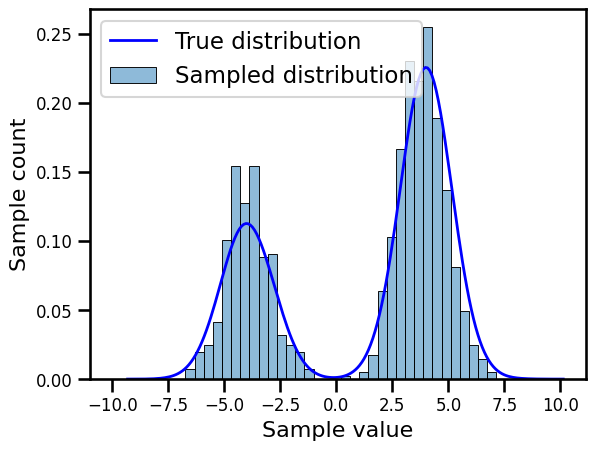

In [ ]:
samples_arr = torch.cat(samples,dim=0).detach().numpy()
samples_history_arr = torch.stack(samples_history,dim=0).squeeze().detach().numpy() # 2D array of dimension 250x1000

# plot the samples
fig, ax = plt.subplots(1, 1)
bins = np.linspace(-10, 10, 50)
sns.kdeplot(dataset, ax=ax, color='blue', label='True distribution', linewidth=2)
sns.histplot(samples_arr, ax=ax, bins=bins, color='red', label='Sampled distribution', stat='density')
ax.legend()
ax.set_xlabel('Sample value')
ax.set_ylabel('Sample count')

In [ ]:
timesteps = np.arange(250)

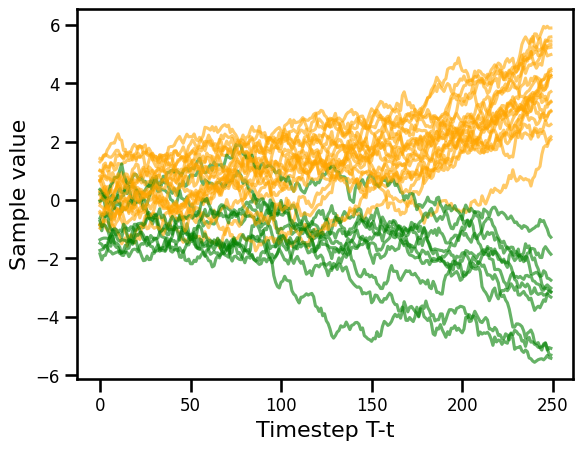

In [ ]:
plt.figure()
plt.xlabel('Timestep T-t')
plt.ylabel('Sample value')
for i in range(0,1000,35):
  if samples_arr[i] > 0.:
    plt.plot(timesteps,samples_history_arr[:,i], color = 'orange', alpha = 0.6)
  else:
    plt.plot(timesteps,samples_history_arr[:,i], color = 'green', alpha = 0.6)
plt.show()